In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from util import *
import os
import torch
import tensorflow as tf
from cnn.model import ConvBlock
import cnn_tf.model as tf_model
import numpy as np

In [ ]:
# disable all tensorflow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [ ]:
# Load config file
file_path = os.path.join(os.getcwd(), 'config_files', 'config2.txt')
config_file = load_yaml(file_path)

## Test ConvBlock

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
conv_block = ConvBlock(kernel = kernel,
                       in_channels = x_torch.shape[3],
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [ ]:
tf_conv_block = tf_model.ConvBlock(kernel = kernel,
                                   strides = stride,
                                   filters = filters,
                                   mu=mu, 
                                   epsilon=epsilon)

In [ ]:
np.isclose(x_torch, x_tf).all()

In [ ]:
y_torch = conv_block(x_torch).detach().numpy()
y_tf = tf_conv_block(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Max Pooling

In [ ]:
from cnn.model import MaxPooling

In [ ]:
# create a a image tensor to test the max pooling layer
max_pool = MaxPooling(kernel=3, strides=1)
tf_max_pool = tf_model.MaxPooling(kernel=3, strides=1)

y_tf = tf_max_pool(x_tf, name="max_pool")
y_torch = max_pool(x_torch).detach().numpy()

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Avg Pooling

In [ ]:
from cnn.model import AvgPooling

avg_pool = AvgPooling(kernel=3, strides=1)
y_torch = avg_pool(x_torch).detach().numpy()

tf_avg_pool = tf_model.AvgPooling(kernel=3, strides=1)
y_tf = tf_avg_pool(x_tf, name='avg_pool')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Fully Connected Layer

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(32, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import FullyConnected

# flatten the tensor
num_features = x_torch.shape[1] * x_torch.shape[2] * x_torch.shape[3]
units = 20

fc_torch = FullyConnected(input_features=num_features, units=units)
fc_tf = tf_model.FullyConnected(units=units)

x_tor = torch.reshape(x_torch, [-1, num_features])
x_tfl = tf.reshape(x_tf, [-1, num_features])

y_torch = fc_torch(x_tor).detach().numpy()
y_tf = fc_tf(x_tfl, name='fc')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test Pad Feature

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 8).astype(np.float32)
X1 = np.random.rand(1, 6, 6, 6).astype(np.float32)

x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

x_torch1 = torch.from_numpy(X1)
x_tf1 = tf.convert_to_tensor(X1, dtype=tf.float32)


In [ ]:
from cnn.model import pad_features

torch_tensors = [x_torch, x_torch1]
tf_tensors = [x_tf, x_tf1]


torch_padded = pad_features(tensors=torch_tensors)
tf_padded = tf_model.pad_features(tensors=tf_tensors)

torch_padded[0].shape, torch_padded[1].shape, tf_padded[0].shape, tf_padded[1].shape

## Test ResidualV1

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import ResidualV1

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1 = ResidualV1(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [ ]:
Res_v1

In [ ]:
tf_Res = tf_model.ResidualV1(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [ ]:
np.isclose(x_torch, x_tf).all()

In [ ]:
y_torch = Res_v1(x_torch).detach().numpy()
y_tf = tf_Res(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

In [ ]:
np.isclose(y_torch, y_tf).all()

## Test ResidualV1Pr

In [ ]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
from cnn.model import ResidualV1Pr

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1Pr = ResidualV1Pr(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [ ]:
Res_v1Pr

In [ ]:
tf_ResPR = tf_model.ResidualV1Pr(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [ ]:
y_torch = Res_v1Pr(x_torch).detach().numpy()
y_tf = tf_ResPR(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

## Test NetworkGraph

In [ ]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph

In [ ]:
phase = 'evolution'
experiment_path = 'my_exp_config2 '
config_file = 'config_files/config2.txt'

In [ ]:
args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10/cifar_tfr_10000',
}

In [ ]:
config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

In [ ]:
fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

In [ ]:
#net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']
net_list = ['max_pool_2_2', 'no_op', 'no_op', 'conv_5_1_64', 'no_op', 'no_op']

In [ ]:
filtered_dict = {key: item for key, item in fn_dict.items() if key in net_list}
filtered_dict

In [ ]:
net = NetworkGraph(num_classes=10, mu=0.99, in_channels=3)

In [ ]:
filtered_dict

In [ ]:
net.create_functions(fn_dict=filtered_dict, net_list=net_list)
net

In [ ]:
X = np.random.rand(32, 64, 64, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [ ]:
logits = net(inputs=x_torch, debug=True)

In [ ]:
logits.shape

In [ ]:
fn_dict_tf

In [ ]:
filtered_dict = {key: item for key, item in fn_dict_tf.items() if key in net_list}

In [ ]:
tf_net = tf_model.NetworkGraph(num_classes=10, mu=0.99)
tf_net.create_functions(fn_dict=filtered_dict)

In [ ]:
tf_logits = tf_net.create_network(inputs=x_tf,net_list=net_list)
tf_logits.shape

## Pytorch Dataset

In [ ]:
from dataloader import CIFAR10_loader, CIFAR100_loader, cifar10_info

In [ ]:
# Example usage CIFAR10_loader
data_path = 'cifar10_data'
train_loader, val_loader = CIFAR10_loader(data_path, limit_data=10000, for_train=True, data_aug=True, batch_size=32)
test_loader = CIFAR10_loader(data_path, limit_data=10000, for_train=False, data_aug=True, batch_size=32)

In [ ]:
print(f"train_loader: {len(train_loader)}, val_loader: {len(val_loader)}, test_loader: {len(test_loader)}")

In [ ]:
min = []
max = []
for batch, (imgs, labels) in enumerate(train_loader):
    print(f"batch: {batch}", end='\r')
    for i in range(len(imgs)):
        #print(f"img{i}: {imgs[i].shape}, label: {labels[i]}")
        #print(f"img{i}: Min={imgs[i].min()}, Max={imgs[i].max()}")
        min.append(imgs[i].min())
        max.append(imgs[i].max())
print("\n")
print(f"Min={np.min(min)}, Max={np.max(max)}")

In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor
unorm = UnNormalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616))

In [ ]:
# plot some images of the pytorch train_loader
import matplotlib.pyplot as plt

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship','truck']
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(cifar10_classes[label])
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

In [ ]:
# Example usage CIFAR10_loader
data_path = 'cifar100_data'
train_loader, val_loader = CIFAR100_loader(data_path, limit_data=10000, for_train=True, data_aug=True, batch_size=32)
test_loader = CIFAR100_loader(data_path, limit_data=10000, for_train=False, data_aug=True, batch_size=32)

In [ ]:
print(f"train_loader: {len(train_loader)}, val_loader: {len(val_loader)}, test_loader: {len(test_loader)}")

In [ ]:
min = []
max = []
for batch, (imgs, labels) in enumerate(train_loader):
    print(f"batch: {batch}", end='\r')
    for i in range(len(imgs)):
        #print(f"img{i}: {imgs[i].shape}, label: {labels[i]}")
        #print(f"img{i}: Min={imgs[i].min()}, Max={imgs[i].max()}")
        min.append(imgs[i].min())
        max.append(imgs[i].max())
print("\n")
print(f"Min={np.min(min)}, Max={np.max(max)}")

In [ ]:
unorm_ = UnNormalize(mean=(0.5071, 0.4865, 0.4411), std=(0.2673, 0.2564, 0.2761))

In [ ]:
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm_(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

# Train and Test

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph

In [3]:
phase = 'evolution'
experiment_path = 'my_exp_config2'
config_file = 'config_files/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']

In [4]:
params = config.train_spec

In [5]:
from cnn.train import fitness_calculation
from cnn.input import cifar10_info

In [6]:
data = {
    "num_classes": 10,
}

In [ ]:
acc = fitness_calculation(id_num="job_0", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
acc

In [7]:
# read a txt file containing the decoded nets
import ast
with open('config_files/decoded_nets.txt', 'r') as f:
    lines = f.readlines()
    decoded_nets = [ast.literal_eval(line) for line in lines]


In [8]:
# print the first 5 decoded nets
for i in range(2):
    print(f"Net {i+1}: {decoded_nets[i]}")

Net 1: ['max_pool_2_2', 'no_op', 'no_op', 'conv_5_1_64', 'no_op', 'no_op']
Net 2: ['avg_pool_2_2', 'conv_1_1_128', 'avg_pool_2_2', 'conv_5_1_128', 'conv_5_1_128', 'no_op']


In [9]:
acc_list = {}

In [10]:
for i, net in enumerate(decoded_nets):
    net_name = f"Net_{i+1}"
    acc = fitness_calculation(id_num=net_name, data_info= data, params=params, fn_dict=fn_dict, net_list=net)
    acc_list[net_name] = acc

Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training without validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch [5/50] - Training loss: 8.252465075916714
Epoch [10/50] - Training loss: 6.296006666289435
Epoch [15/50] - Training loss: 5.464469856686062
Epoch [20/50] - Training loss: 5.084968633121914
Epoch [25/50] - Training loss: 4.687169035275777
Epoch [30/50] - Training loss: 4.407779269748264
Epoch [35/50] - Training loss: 4.259952154424456
Epoch [40/50] - Training loss: 4.152495940526326
Epoch [45/50] - Training loss: 3.934497515360514


Training with validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch [46/50] - Training loss: 3.9586230516433716 - Validation loss: 5.370665073394775 - Validation accuracy: 24.8%
Epoch [47/50] - Training loss: 3.852294478151533 - Validation loss: 6.6250468492507935 - Validation accuracy: 19.9%
Epoch [48/50] - Training loss: 3.909897188345591 - Validation loss: 5.646809101104736 - Validation accuracy: 21.9%
Epoch [49/50] - Training loss: 3.873521818055047 - Validation loss: 4.587705016136169 - Validation accuracy: 27.5%
Epoch [50/50] - Training loss: 3.7990242375267878 - Validation loss: 4.789949297904968 - Validation accuracy: 24.9%
Best Validation Accuracy: 27.5%
Training time: 1.581 minutes
Files already downloaded and verified
Files already downloaded and verified
All set for training!


...

Epoch [46/50] - Training loss: 1.514333917034997 - Validation loss: 2.6718153953552246 - Validation accuracy: 37.5%
Epoch [47/50] - Training loss: 1.501833203766081 - Validation loss: 1.973827302455902 - Validation accuracy: 46.7%
Epoch [48/50] - Training loss: 1.5207514365514119 - Validation loss: 2.26259446144104 - Validation accuracy: 41.3%
Epoch [49/50] - Training loss: 1.4609850015905168 - Validation loss: 2.2856615781784058 - Validation accuracy: 40.7%
Epoch [50/50] - Training loss: 1.4955757558345795 - Validation loss: 1.9374822676181793 - Validation accuracy: 47.4%
Best Validation Accuracy: 47.4%
Training time: 1.583 minutes
Files already downloaded and verified
Files already downloaded and verified
All set for training!


Training without validation:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch [5/50] - Training loss: 6.419928815629747
Epoch [10/50] - Training loss: 4.384571366839939
Epoch [15/50] - Training loss: 3.7469575338893466
Epoch [20/50] - Training loss: 3.2964743177096048
Epoch [25/50] - Training loss: 3.1047724419169955
Epoch [30/50] - Training loss: 2.851383215851254
Epoch [35/50] - Training loss: 2.7108464572164745
Epoch [40/50] - Training loss: 2.584231628312005
Epoch [45/50] - Training loss: 2.5142015053166284


Training with validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch [46/50] - Training loss: 2.4283664557668896 - Validation loss: 2.9588884711265564 - Validation accuracy: 30.3%
Epoch [47/50] - Training loss: 2.453758693403668 - Validation loss: 3.199294090270996 - Validation accuracy: 31.0%
Epoch [48/50] - Training loss: 2.4632001320521035 - Validation loss: 4.47992205619812 - Validation accuracy: 22.3%
Epoch [49/50] - Training loss: 2.4268456829918756 - Validation loss: 4.183721661567688 - Validation accuracy: 23.2%
Epoch [50/50] - Training loss: 2.406047304471334 - Validation loss: 3.1319692730903625 - Validation accuracy: 27.5%
Best Validation Accuracy: 31.0%
Training time: 1.54 minutes


In [11]:
acc_list

{'Net_1': 27.5,
 'Net_2': 47.2,
 'Net_3': 35.7,
 'Net_4': 23.8,
 'Net_5': 44.2,
 'Net_6': 27.1,
 'Net_7': 59.1,
 'Net_8': 48.8,
 'Net_9': 27.4,
 'Net_10': 33.9,
 'Net_11': 47.4,
 'Net_12': 31.0}

In [12]:
import pandas as pd
df = pd.DataFrame.from_dict(acc_list, orient='index', columns=['accuracy'])
df = df.sort_values(by=['accuracy'], ascending=False)

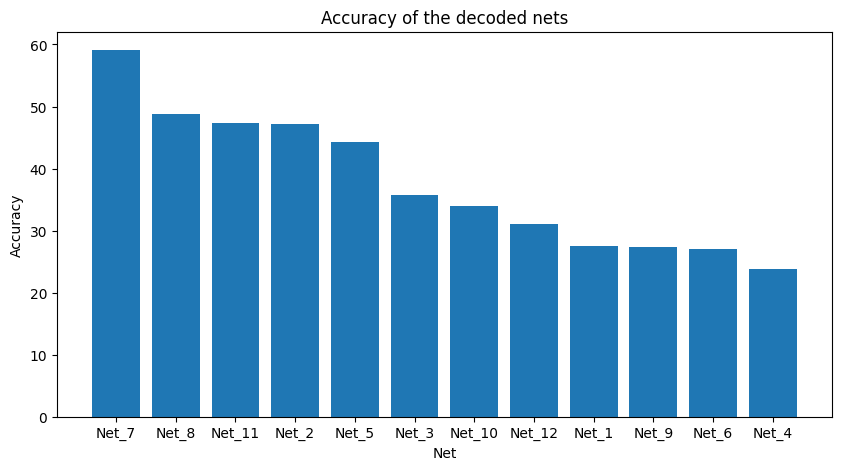

In [17]:
# plot the accuracy of the decoded nets
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(df.index, df['accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Net')
plt.title('Accuracy of the decoded nets')
plt.show()